In [1]:
library(conText)
library(quanteda)
library(dplyr)
library(ggplot2)

conText v3.0.1 successfully loaded. Note this version of the package comes with significant changes to the conText() function.
                        See Quick Start Guide for help getting started and instructions for accessing older versions of the package:
 https://github.com/prodriguezsosa/conText/blob/master/vignettes/quickstart.md

Package version: 4.3.1
Unicode version: 15.0
ICU version: 73.2

Parallel computing: disabled

See https://quanteda.io for tutorials and examples.


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




### Politicization score

In [17]:
results_df <- readRDS("Results_Files/ALC_ideology_results_df.rds")
results_df_party <- readRDS("Results_Files/ALC_party_results_df.rds")

In [19]:
# Create politicization score
results_df <- results_df %>%  
    mutate(pol_score = (cos_liberal_mean + cos_con_mean)/2,
           pol_score_upper = (cos_liberal_upper + cos_con_upper)/2,
           pol_score_lower = (cos_liberal_lower + cos_con_lower)/2) %>%
    mutate(group = "ideology") %>%
    select("term", "year", "topic", "label", "pol_score", "pol_score_upper", "pol_score_lower", "group", "frequency")

results_df_party <- results_df_party %>%
    mutate(pol_score = (cos_dem_mean + cos_rep_mean)/2,
           pol_score_upper = (cos_dem_upper + cos_rep_upper)/2,
           pol_score_lower = (cos_dem_lower + cos_rep_lower)/2) %>%
    mutate(group = "party") %>%
    select("term", "year", "topic", "label", "pol_score", "pol_score_upper", "pol_score_lower", "group", "frequency")

In [23]:
cor(results_df$pol_score, results_df$frequency, use="complete.obs")

[1] 0.5209071

In [28]:
cor(results_df_party$pol_score, results_df_party$frequency, use="complete.obs")

[1] 0.5147812

In [29]:
summary(lm(pol_score ~ frequency + year, data=results_df))


Call:
lm(formula = pol_score ~ frequency + year, data = results_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.27951 -0.04583 -0.00896  0.03784  0.45533 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.289e+00  2.838e-02  -80.66   <2e-16 ***
frequency    6.857e-05  2.956e-07  231.93   <2e-16 ***
year         1.222e-03  1.418e-05   86.19   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.07051 on 148795 degrees of freedom
  (2717 observations deleted due to missingness)
Multiple R-squared:  0.306,	Adjusted R-squared:  0.306 
F-statistic: 3.28e+04 on 2 and 148795 DF,  p-value: < 2.2e-16


### Create bigger categories

In [9]:
results_df_cat <- 
    rbind(results_df, results_df_party) %>%
    filter(frequency >= 100) %>%  ## appear at least 100 times in any given year
    mutate(Category = case_when(
      label %in% c("Abortion", "Gender", "LGBTQ", "Marriage", "Parenting") ~ "Gender and Family",
      label %in% c("Catholicism", "Religion") ~ "Religion",
      label %in% c("Minority", "Native_American", "Racial", "Confederate", "Immigration") ~ "Race and Immigration",
      label %in% c("Campaigns & Donors", "Protest", "PublicOpinion", "Senate", "Elections") ~ "Politics",
      label %in% c("CriminalJustice", "Investigation", "Criminal", "Burglary", 
                   "Homicide", "Police") ~ "Crime and Policing",
      label %in% c("Constitution_Law", "Judicial", "Lawsuit", "SupremeCourt") ~ "Legal Institution",
      label %in% c("Higher_Education", "Education") ~ "Education",
      label %in% c("Science") ~ "Science",
      label %in% c("Gun_Control") ~ "Gun",
      label %in% c("Bankruptcy", "Banks", "Commodity_Market", "Corporate", "CorporateFinance",
                   "Earnings", "ExecutiveCompensation", "Financial", "Investing", "Money_Markets",
                   "Retail", "Securities",
                   "Stock_market", "Foreign_exchange") ~ "Financial Market",
      label %in% c("Welfare & Poverty", "Taxation", "Economics", "Agriculture", "Business",
                   "Economy", "Fiscal", "Labor", "Workers", "MonetaryPolicy", "Trade") ~ "Economic Issues",
      label %in% c("Housing", "Urban_development", "Mortgage", "Architecture") ~ "Housing",
      label %in% c("China", "Espionage", "Latin_America", "Middle_East",
                   "MiddleEastConflict", "Military", "NuclearArms", "Terrorism", "Russia & Ukraine") ~ "Foreign Affairs",
      label %in% c("ClimateChange", "Disaster", "Air Pollution",
                   "Weather", "Wildfires") ~ "Environment",
      label %in% c("Healthcare", "Hospital", "MentalHealth", "Nutrition", "Pharmaceuticals",
                   "Substance Abuse", "Vaccine", "Disease") ~ "Health",
      label %in% c("Art",  "Broadway",  "Classical_Music", 
                      "Museum", "Fashion", 
                      "Literature", "Movie", "Music") ~ "Creative Arts",
      label %in% c("Festival", "TravelIndustry", "Horticulture", "Nature", "Gaming") ~ "Leisure",
      label %in% c("Culinary", "Dining",  "Wine", "Beverage") ~ "Food & Drinks",
      label %in% c("Journalism", "Radio", "Television", "TV_Entertainment") ~ "Media",
      label %in% c("AmericanFootball", "Baseball", "NBA", "NFL", "Boxing",
                   "CollegeSports", "Golf", "NHL", "Soccer",  "Tennis") ~ "Sports",
      label %in% c("Electricity", "Energy", "Postal_service",  "Telecommunications", "Water") ~ "Infrastructure",
      label %in% c("Maritime",  "Mass_Transit", "Airline", "Automotive",
                    "Railroad", "Traffic", "Transportation") ~ "Transportation",
      label %in% c("Animal", "Marine_Biology",  "Wildlife") ~ "Animals",
      label %in% c("Home", "Household", "Cooking") ~ "Home",
      label == "Space" ~ "Outer Space",
      TRUE ~ "Other"))

In [38]:
results_df_cat %>%
    group_by(year, group) %>%
    summarise(value_avg = mean(pol_score, na.rm=TRUE)) %>%
    ungroup() %>%
    arrange(value_avg)

`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


year,group,value_avg
<dbl>,<chr>,<dbl>
1993,ideology,0.1890389
1996,ideology,0.1937403
2005,party,0.1949708
1998,ideology,0.1951494
1993,party,0.1965832
1991,ideology,0.1966414
2001,party,0.1966724
1995,ideology,0.1972771
1990,party,0.1973339


## Category Level Graphs

### Overall Graph

`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


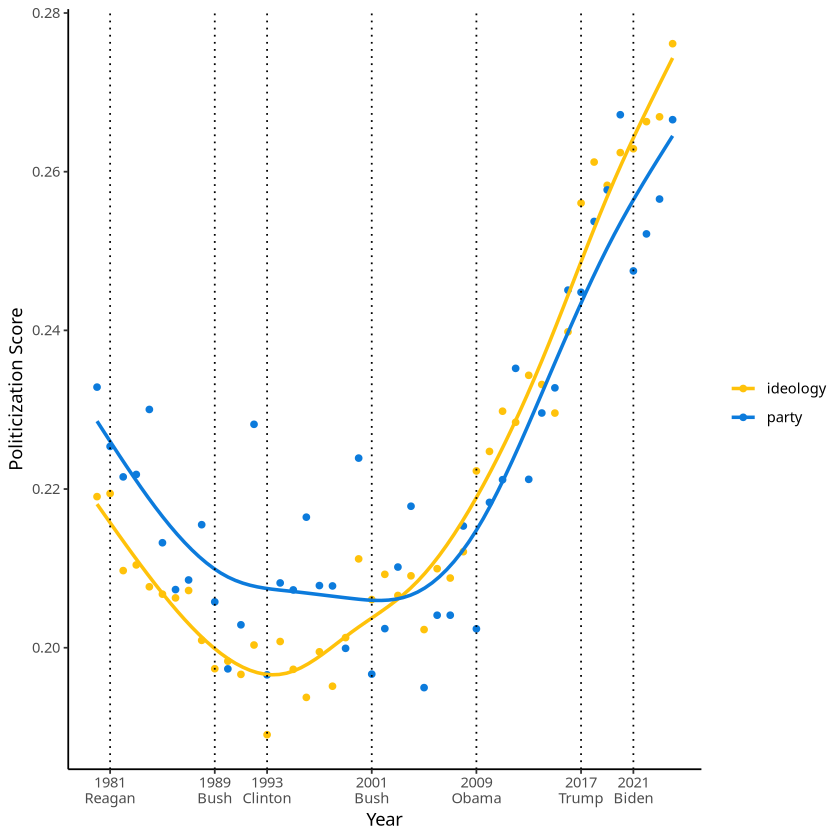

In [11]:
president <- data.frame(xintercepts = c(1981, 1989, 1993, 2001, 2009, 2017, 2021))

results_df_cat %>%
    group_by(year, group) %>%
    summarise(value_avg = mean(pol_score, na.rm=TRUE)) %>%
    ungroup() %>%
    ggplot(aes(x= year, y=value_avg, color = group)) +
    geom_point() +
    geom_smooth(method = "gam", se=FALSE) +
    geom_vline(data = president, aes(xintercept = xintercepts), linetype = "dotted") +
    scale_x_continuous(
        breaks = c(1981, 1989, 1993, 2001, 2009, 2017, 2021),
        labels = c("1981\nReagan", "1989\nBush", "1993\nClinton",
                   "2001\nBush", "2009\nObama", "2017\nTrump", "2021\nBiden")) +
    scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
    theme_classic() +
    labs(x = "Year",
         y = "Politicization Score") + 
    guides(color = guide_legend(title = "")) +
    theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [12]:
ggsave("Figure1_politicization_overall_highfreq.png")

Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


### Graph - Most and Least Politicized

In [30]:
category_year <- results_df_cat %>%
  group_by(year, Category, group) %>%
  summarise(
    value_avg   = mean(pol_score,   na.rm = TRUE),
    value_upper = mean(pol_score_upper, na.rm = TRUE),
    value_lower = mean(pol_score_lower, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(year0 = year - 1980)

head(category_year)

year,Category,group,value_avg,value_upper,value_lower,year0
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1980,Animals,ideology,0.2256198,0.2507670,0.2013862,0
1980,Animals,party,0.2400969,0.2632825,0.2155411,0
1980,Creative Arts,ideology,0.2304252,0.2527304,0.2079916,0
1980,Creative Arts,party,0.2187182,0.2392562,0.1981536,0
1980,Crime and Policing,ideology,0.1882702,0.2100812,0.1656351,0
1980,Crime and Policing,party,0.2344195,0.2558455,0.2129281,0


In [32]:
polscore_cat_rawvalues <- 
  category_year %>%
  group_by(Category, group) %>%
  summarise(
    early_value  = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_upper  = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower  = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  arrange(desc(late_value))

`summarise()` has grouped output by 'Category'. You can override using the
`.groups` argument.


In [33]:
order_ideo <-
    polscore_cat_rawvalues %>% 
    filter(group == "ideology") %>%
    arrange(desc(late_value))

order_ideo

Category,group,early_value,early_upper,early_lower,late_value,late_upper,late_lower
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Politics,ideology,0.3390058,0.3663237,0.3125114,0.3990170,0.4228416,0.3767174
Race and Immigration,ideology,0.2812350,0.3085765,0.2546790,0.3358755,0.3602905,0.3128498
Legal Institution,ideology,0.2278596,0.2514578,0.2038522,0.3226010,0.3460218,0.2995075
Religion,ideology,0.2461298,0.2742297,0.2176904,0.3201805,0.3484055,0.2928645
Gender and Family,ideology,0.2526731,0.2780207,0.2277076,0.3191114,0.3430036,0.2958258
Education,ideology,0.2443297,0.2685389,0.2199261,0.3096864,0.3321704,0.2878826
Economic Issues,ideology,0.2415898,0.2647354,0.2186730,0.2788795,0.3003566,0.2579145
Media,ideology,0.2340178,0.2578889,0.2100256,0.2729037,0.2954403,0.2506386
Foreign Affairs,ideology,0.2180261,0.2435663,0.1924357,0.2659562,0.2895027,0.2427286


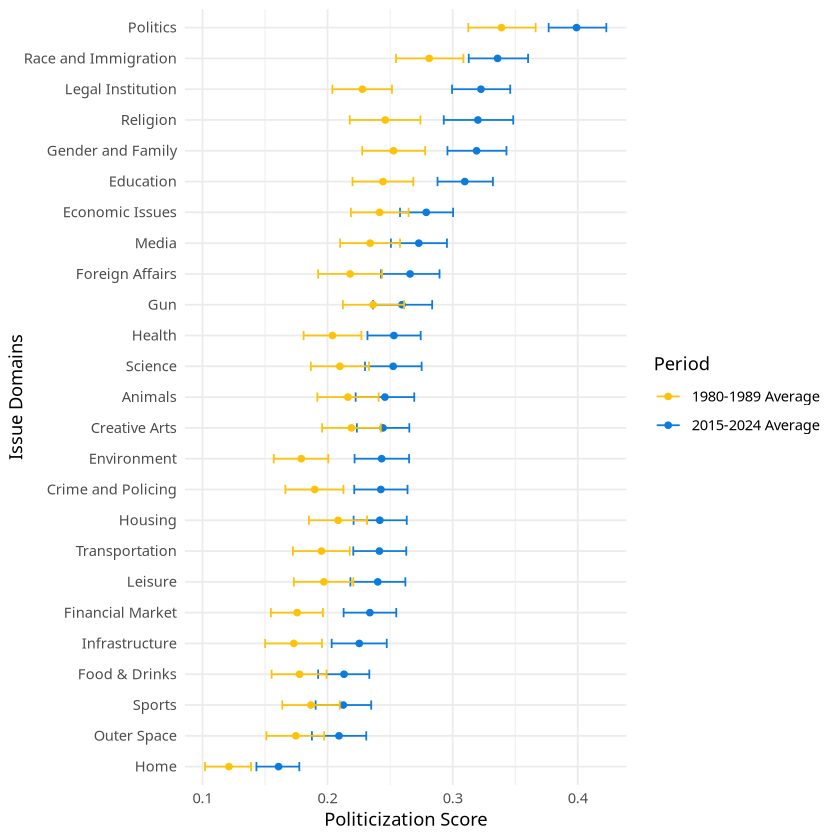

In [34]:
category_year %>%
  group_by(Category) %>%
  filter(group == "ideology") %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  mutate(early_rank = min_rank(desc(early_value)),
         late_rank = min_rank(desc(late_value))) %>%
  ggplot(aes(y = reorder(Category, late_value))) +
  geom_point(aes(x = late_value, color = "2015-2024 Average"),
             position = position_dodge(width = 0.3)) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper,
                    color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper,
                    color = "1980-1989 Average"), width = 0.3) +
  scale_alpha_manual(values = c(0.5, 1.0)) +
  scale_linetype_manual(values = c("dashed", "solid")) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score",
       y = "Issue Domains") +
  guides(color = guide_legend(title = "Period")) +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [35]:
ggsave("Figure3_politicization_ideo_HighFreq.png", width =6.5, height = 7)

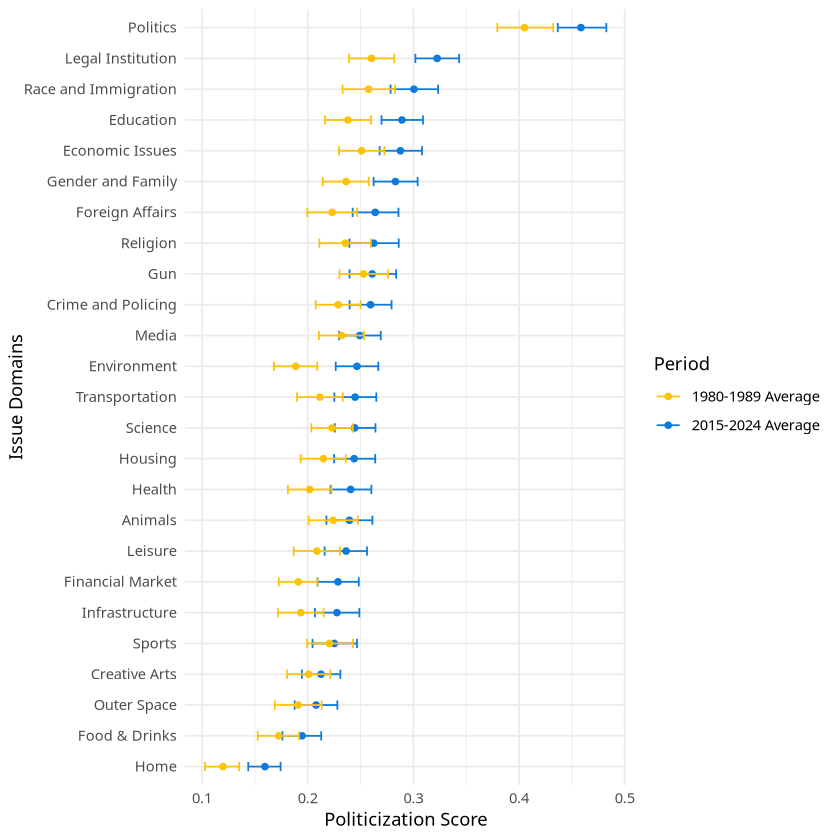

In [36]:
category_year %>%
  group_by(Category) %>%
  filter(group == "party") %>%
  summarise(
    late_value  = mean(value_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_avg[year >= 1980 & year <= 1989], na.rm = TRUE),
    late_upper  = mean(value_upper[year >= 2015 & year <= 2024], na.rm = TRUE),
    late_lower  = mean(value_lower[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_upper = mean(value_upper[year >= 1980 & year <= 1989], na.rm = TRUE),
    early_lower = mean(value_lower[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  mutate(early_rank = min_rank(desc(early_value)),
         late_rank = min_rank(desc(late_value))) %>%
  ggplot(aes(y = reorder(Category, late_value))) +
  geom_point(aes(x = late_value, color = "2015-2024 Average"),
             position = position_dodge(width = 0.3)) +
  geom_errorbar(aes(xmin = late_lower, xmax = late_upper,
                    color = "2015-2024 Average"), width = 0.3) +
  geom_point(aes(x = early_value, color = "1980-1989 Average")) +
  geom_errorbar(aes(xmin = early_lower, xmax = early_upper,
                    color = "1980-1989 Average"), width = 0.3) +
  scale_alpha_manual(values = c(0.5, 1.0)) +
  scale_linetype_manual(values = c("dashed", "solid")) +
  scale_color_manual(values = c("#FFC20A", "#0C7BDC")) +
  labs(x = "Politicization Score",
       y = "Issue Domains") +
  guides(color = guide_legend(title = "Period")) +
  theme_minimal() +
  theme(plot.title = element_text(size= 20), 
          plot.subtitle=element_text(size=18), 
          strip.text = element_text(size = 15))

In [37]:
ggsave("Figure4_politicization_party_HighFreq.png", width = 6.5, height = 7)